# RQ2: Feature Group Effectiveness (ML Dataset)

**Research question:** How does the use of different feature groups, including content-related, platform-related, temporal, and creator-related features, affect prediction performance?

## 1. Setup

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
TARGET = "trend_label"

pd.set_option("display.max_columns", 100)


## 2. Load ML Processed Data

In [ ]:
train = pd.read_csv("../../data/processed_ml/train.csv")
validation = pd.read_csv("../../data/processed_ml/validation.csv")
test = pd.read_csv("../../data/processed_ml/test.csv")
feature_group_table = pd.read_csv("../../data/processed_ml/feature_groups.csv")

X_train = train.drop(columns=TARGET)
y_train = train[TARGET]

X_val = validation.drop(columns=TARGET)
y_val = validation[TARGET]

X_test = test.drop(columns=TARGET)
y_test = test[TARGET]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

display(y_train.value_counts(normalize=True).sort_index())

Train: (35000, 72) (35000,)
Validation: (7500, 72) (7500,)
Test: (7500, 72) (7500,)


trend_label
declining    0.101971
rising       0.250000
seasonal     0.094114
stable       0.553914
Name: proportion, dtype: float64

## 3. Feature Groups

In [3]:
feature_groups = {
    group: group_df["feature"].tolist()
    for group, group_df in feature_group_table.groupby("feature_group")
}

feature_groups = {
    group: [column for column in columns if column in X_train.columns]
    for group, columns in feature_groups.items()
}
feature_groups["all_features"] = X_train.columns.tolist()

feature_group_summary = pd.DataFrame([
    {"feature_group": group, "n_columns": len(columns)}
    for group, columns in feature_groups.items()
]).sort_values("feature_group")

display(feature_group_summary)

,feature_group,n_columns
5,all_features,72
0,content_basic,2
1,creator,5
2,engagement_observed,11
3,interactions,4
4,metadata,50


## 4. Group Experiments with Three Models

Each feature group is evaluated with three non-neural models: `LogisticRegression`, `KNeighborsClassifier`, and `RandomForestClassifier`. Macro F1 is the main comparison metric because the task is multi-class and each class should count equally.

In [4]:
models = {
    "logistic_regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    ),
    "knn": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=15, weights="distance", n_jobs=-1),
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=100,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_val)

rows = [{
    "model": "majority_baseline",
    "feature_group": "none",
    "n_columns": 0,
    "accuracy": accuracy_score(y_val, baseline_pred),
    "macro_f1": f1_score(y_val, baseline_pred, average="macro"),
}]
trained_models = {}

for model_name, model in models.items():
    for group_name, columns in feature_groups.items():
        fitted_model = clone(model)
        fitted_model.fit(X_train[columns], y_train)
        y_pred = fitted_model.predict(X_val[columns])

        rows.append({
            "model": model_name,
            "feature_group": group_name,
            "n_columns": len(columns),
            "accuracy": accuracy_score(y_val, y_pred),
            "macro_f1": f1_score(y_val, y_pred, average="macro"),
        })
        trained_models[(model_name, group_name)] = fitted_model

results = pd.DataFrame(rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
display(results.round(4))

,model,feature_group,n_columns,accuracy,macro_f1
0,random_forest,all_features,72,0.8027,0.7773
1,logistic_regression,all_features,72,0.7484,0.7263
2,random_forest,interactions,4,0.7011,0.6789
3,knn,interactions,4,0.7140,0.6612
4,logistic_regression,interactions,4,0.6615,0.6511
5,random_forest,engagement_observed,11,0.7272,0.5784
6,knn,engagement_observed,11,0.7341,0.5615
7,logistic_regression,engagement_observed,11,0.5311,0.5120
8,knn,all_features,72,0.6628,0.4308
9,random_forest,metadata,50,0.3245,0.2874


model,knn,logistic_regression,random_forest
feature_group,,,
content_basic,0.1932,0.1926,0.1926
creator,0.2269,0.1737,0.1737
metadata,0.2684,0.2426,0.2874
engagement_observed,0.5615,0.5120,0.5784
interactions,0.6612,0.6511,0.6789
all_features,0.4308,0.7263,0.7773


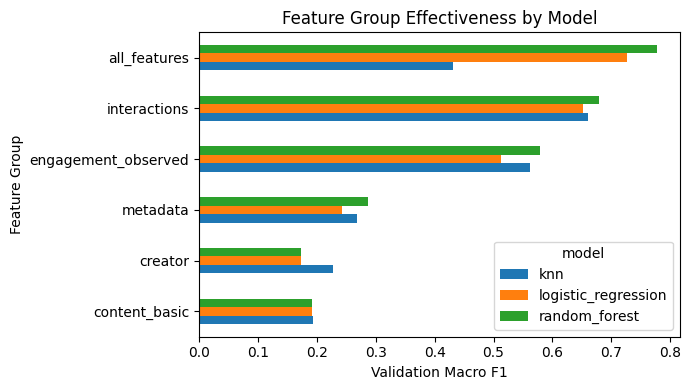

In [5]:
validation_pivot = (
    results[results["model"] != "majority_baseline"]
    .pivot(index="feature_group", columns="model", values="macro_f1")
)
validation_pivot = validation_pivot.loc[validation_pivot.max(axis=1).sort_values().index]

display(validation_pivot.round(4))

validation_pivot.plot(kind="barh", figsize=(7, 4))
plt.xlabel("Validation Macro F1")
plt.ylabel("Feature Group")
plt.title("Feature Group Effectiveness by Model")
plt.tight_layout()
plt.show()

## 5. Best Validation Combination on Test Set

In [6]:
best_row = results[results["model"] != "majority_baseline"].iloc[0]
best_model_name = best_row["model"]
best_group = best_row["feature_group"]
best_columns = feature_groups[best_group]
best_model = trained_models[(best_model_name, best_group)]

y_test_pred = best_model.predict(X_test[best_columns])

test_scores = pd.DataFrame([{
    "model": best_model_name,
    "feature_group": best_group,
    "n_columns": len(best_columns),
    "accuracy": accuracy_score(y_test, y_test_pred),
    "macro_f1": f1_score(y_test, y_test_pred, average="macro"),
}])

display(test_scores.round(4))
print(classification_report(y_test, y_test_pred, digits=3))

,model,feature_group,n_columns,accuracy,macro_f1
0,random_forest,all_features,72,0.8112,0.7822


              precision    recall  f1-score   support

   declining      0.655     0.869     0.747       765
      rising      0.757     0.766     0.762      1875
    seasonal      0.821     0.715     0.765       706
      stable      0.875     0.837     0.856      4154

    accuracy                          0.811      7500
   macro avg      0.777     0.797     0.782      7500
weighted avg      0.818     0.811     0.813      7500



## 6. Summary

The ML-preprocessed dataset changes the feature-group results substantially compared with the original CSV. In the original feature-group notebook, the best validation result was `random_forest` with `all_features`, but it reached only about 0.260 validation macro F1 and 0.248 test macro F1. That was close to chance and only weakly better than the baseline in accuracy. In the ML version, `random_forest` with `all_features` is again the best validation combination, but it reaches 0.777 validation macro F1 and 0.782 test macro F1, with test accuracy about 0.811.

The feature groups are also different in the ML dataset. The full ML feature matrix has 72 encoded columns, compared with 203 encoded columns in the original processed data. The strongest single group is `interactions`: Random Forest using only the four interaction features reaches about 0.679 validation macro F1, and KNN and Logistic Regression on the same group also perform strongly. This shows that the engineered interaction terms carry substantial predictive signal on their own.

`engagement_observed` is the next strongest single feature group, with Random Forest reaching about 0.578 validation macro F1. Metadata alone performs much worse, with the best metadata result around 0.287 validation macro F1, and `content_basic` and `creator` features are close to or below the majority baseline by macro F1. This contrasts with the original CSV, where no group was strongly predictive and all macro F1 values clustered around 0.25.

Overall answer to RQ2: using all ML features gives the best performance, but the improvement is driven mainly by engineered interaction and engagement features. The ML dataset provides clear evidence that feature-group choice matters, while the original CSV did not show a meaningful separation between groups. For reporting, the key result is that `all_features` performs best, `interactions` is the strongest standalone group, and simple metadata, creator, and content-basic features are much less effective.